# Mutually Coupled Duffin-VanDerPol System Analysis

## Eqn setup:
$$\dot{x_1} = v_1$$
$$\dot{v_1} = - \mu_1 (x_1^2 - 1) v_1 - \omega_1^2 x_1 - \alpha x_1^3 - k (x_1 - x_2) + F_1 cos(\Omega t)$$
$$\dot{x_2} = v_2$$
$$\dot{v_2} = - \mu_2 (x_2^2 - 1) v_2 - \omega_2^2 x_2 - \alpha x_2^3 - k (x_2 - x_1) + F_2 cos(\Omega t)$$


* $\mu_1$: Van der Pol damping, oscillator 1
* $\mu_2$: Van der Pol damping, oscillator 2
* $\omega_1$: natural frequency, oscillator 1
* $\omega_2$: natural frequency, oscillator 2 (slight detuning for chaos)
* $\alpha_1$: Duffing nonlinearity (cubic stiffness), oscillator 1
* $\alpha_2$: Duffing nonlinearity, oscillator 2
* $k$: mutual coupling strength
* $F_1$: external forcing amplitude, oscillator 1
* $F_2$: external forcing amplitude, oscillator 2
* $\Omega$: external forcing frequency (shared)

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000

#Meta stuff
from ExperimentTracker import ExperimentTracker
from time import time
from Logger import Logger
import ipynbname
import os
NOTEBOOK_NAME = ipynbname.name()
OP_DIR = os.path.join(os.path.curdir, "Outputs")

from Helpers import read_json_config, time_format
PARAM_CONFIG_DIR = os.path.join(os.path.curdir, "DVPParams.config")
PARAMS = read_json_config(PARAM_CONFIG_DIR)

tracker = ExperimentTracker(os.path.abspath(OP_DIR))


#Plot properties
ASPECT_RATIO_INV = 3/4
DPI = 1000
LINE_WIDTH = 0.1
DOT_RADIUS = 0.1
SCATTER_LW = 0

"""Temporary"""
PARAMS['t_start'] = 0
PARAMS['t_end'] = 500
PARAMS['transient_drop_frac'] = 0.3


# DEFAULT_PARAMS = {
#     'mu1':   0.3, 
#     'mu2':   0.3, 
#     'omega1': 1.0,
#     'omega2': 1.5,
#     'alpha1': 1.0,
#     'alpha2': 1.0,
#     'k':      5,
#     'F1':     0.5,
#     'F2':     0.5,
#     'Omega':  0.8,
# }


%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
def dvp_coupled(t, state, params):
    """
    Equations of motion for the mutually coupled Duffing-Van der Pol system.

    State vector: [x1, v1, x2, v2]
        x1, x2 : displacements
        v1, v2 : velocities
    """
    x1, v1, x2, v2 = state
    p = params

    dx1 = v1
    dv1 = (-p['mu1'] * (x1**2 - 1) * v1
            - p['omega1']**2 * x1
            - p['alpha1'] * x1**3
            - p['k'] * (x1 - x2)
            + p['F1'] * np.cos(p['Omega'] * t))

    dx2 = v2
    dv2 = (-p['mu2'] * (x2**2 - 1) * v2
            - p['omega2']**2 * x2
            - p['alpha2'] * x2**3
            - p['k'] * (x2 - x1)
            + p['F2'] * np.cos(p['Omega'] * t))

    return [dx1, dv1, dx2, dv2]

In [ ]:
def vdp_duffing_coupled(t, state, params):
    """
    Oscillator 1: Van der Pol  (alpha1 = 0, omega1 drives limit cycle)
    Oscillator 2: Duffing      (mu2 = 0, double well potential)
    Coupling: position difference
    """
    x1, v1, x2, v2 = state
    p = params

    # Van der Pol oscillator
    dx1 = v1
    dv1 = (-p['mu1'] * (x1**2 - 1) * v1
            - p['omega1']**2 * x1
            - p['k'] * (x1 - x2)
            + p['F1'] * np.cos(p['Omega'] * t))

    # Duffing oscillator (double well: negative linear term)z
    dx2 = v2
    dv2 = (-p['mu2'] * v2
            + p['omega2']**2 * x2        # positive sign = double well
            - p['alpha2'] * x2**3
            - p['k'] * (x2 - x1)
            + p['F2'] * np.cos(p['Omega'] * t))

    return [dx1, dv1, dx2, dv2]

In [ ]:
def simulate(params=None, x0=None, t_span=(0, 200), ts_per_sec=100, verbose=True):
    """
    Integrate the coupled DVP system.
    Returns:
        time array and state array, shape (4, len(t))
    """
    if params is None:
        params = PARAMS
    if x0 is None:
        x0 = [0.1, 0.0, -0.1, 0.0] 


    t_eval = np.arange(t_span[0], t_span[1], 1/ts_per_sec)
    
    start_time = time()

    sol = solve_ivp(
        fun=lambda t, y: vdp_duffing_coupled(t, y, params),
        t_span=t_span,
        y0=x0,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-9,
        atol=1e-9,
        dense_output=False
    )

    duration = time() - start_time
    msg = ""
    if verbose:
        msg+= (f"Simulated {(t_span[1] - t_span[0])*ts_per_sec} steps for {len(x0)} states in [{time_format(duration)}].")
        msg+=("\nParameters:")
        for key,value in PARAMS.items():
            msg+=(f"\n\t{key:20} {value}")
    return sol.t, sol.y, msg

def drop_transient(t, sol, frac=0.3):
    """
    Drop the transient part
    to call this before plotting attractors or computing indicators.
    """
    n = int(len(t) * frac)
    return t[n:], sol[:, n:]
def plot_phase_portrait(sol, title="Phase Portrait", save_path=None):
    """
    Plot x vs v for both oscillators side by side.
    Call drop_transient first.
    """

    global OP_DIR, NOTEBOOK_NAME

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for i, ax in enumerate(axes):
        ax.plot(sol[2*i], sol[2*i + 1], lw=LINE_WIDTH, color='steelblue', alpha=0.8)
        ax.set_xlabel(f'$x_{i+1}$')
        # ax.set_ylabel(f'$\\dot{{x}}_{i+1}$')
        ax.set_ylabel(f'$\\frac{{dx_{i+1}}}{{dt}}$')
        ax.set_title(f'Oscillator {i+1}')
        ax.grid(True, alpha=0.3)
        ax.set_box_aspect(ASPECT_RATIO_INV)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    # run.get_path("plots")
    save_path = "" if save_path == None else save_path
    
    fig.savefig(os.path.join(save_path, f"{NOTEBOOK_NAME}_out_FP.png"), dpi=DPI)

def plot_poincare(ps, title="Poincare Section", save_path = None):
    """
    Plot stroboscopic Poincare section for both oscillators.
    Pass the output of poincare_section() directly.
    """

    global OP_DIR, NOTEBOOK_NAME

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for i, ax in enumerate(axes):
        ax.scatter(ps[2*i], ps[2*i + 1], s=DOT_RADIUS, color='crimson', alpha=0.7)
        ax.set_xlabel(f'$x_{i+1}$')
        ax.set_ylabel(f'$\\frac{{dx_{i+1}}}{{dt}}$')
        ax.set_title(f'Oscillator {i+1}')
        ax.grid(True, alpha=0.3)
        ax.set_box_aspect(ASPECT_RATIO_INV)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    save_path = "" if save_path == None else save_path
    fig.savefig(os.path.join(save_path, f"{NOTEBOOK_NAME}_out_PS.png"), dpi=DPI)
    
def poincare_section(t, sol, params, dt=0.01, transient_frac=0.3):
    """
    Stroboscopic Poincare section on the FULL trajectory.
    Drops transient internally before sampling.
    """
    T = 2 * np.pi / params['Omega']
    period_steps = int(round(T / dt))

    #drop transient
    n_drop = int(len(t) * transient_frac)
    sol_trimmed = sol[:, n_drop:]

    #Sample every forcing period
    indices = np.arange(0, sol_trimmed.shape[1], period_steps)
    sampled = sol_trimmed[:, indices]

    return sampled

In [ ]:
def compute_mle(params, x0=None, t_span=(0, 500), ts_per_sec=100,
             eps=1e-8, renorm_interval=10, transient_frac=0.2):
    """
    Maximal Lyapunov Exponent via renormalization method.

    eps              : initial perturbation size
    renorm_interval  : time between renormalizations (in seconds)
    """
    if x0 is None:
        x0 = [0.1, 0.0, -0.1, 0.0]

    dt = 1 / ts_per_sec
    renorm_steps = int(renorm_interval * ts_per_sec)

    # run reference trajectory first to get off transient
    t_full, sol_full, msg = simulate(params=params, x0=x0,
                                t_span=t_span, ts_per_sec=ts_per_sec)
    n_drop = int(len(t_full) * transient_frac)
    x_ref = sol_full[:, n_drop] #Start MLE from here

    # perturbed initial condition
    x_pert = x_ref.copy()
    x_pert[0] += eps

    lyapunov_sum = 0.0
    n_renorm     = 0
    growth_log   = [] #To track convergence over time

    t_current = t_full[n_drop]

    while t_current < t_span[1]:
        t_end = min(t_current + renorm_interval, t_span[1])

        #Integrate both trajectories forward by renorm_interval
        sol_ref = solve_ivp(
            fun=lambda t, y: vdp_duffing_coupled(t, y, params),
            t_span=(t_current, t_end),
            y0=x_ref,
            method='RK45', rtol=1e-9, atol=1e-9,
            dense_output=False
        )
        sol_per = solve_ivp(
            fun=lambda t, y: vdp_duffing_coupled(t, y, params),
            t_span=(t_current, t_end),
            y0=x_pert,
            method='RK45', rtol=1e-9, atol=1e-9,
            dense_output=False
        )

        x_ref  = sol_ref.y[:, -1]
        x_pert = sol_per.y[:, -1]

        #Check separation
        delta      = x_pert - x_ref
        delta_norm = np.linalg.norm(delta)

        if delta_norm == 0:
            break

        #Log growth
        lyapunov_sum += np.log(delta_norm / eps)
        n_renorm     += 1

        #Renormalize perturbation
        x_pert = x_ref + eps * (delta / delta_norm)

        t_current = t_end

        #Running estimate
        mle_running = lyapunov_sum / (n_renorm * renorm_interval)
        growth_log.append((t_current, mle_running))

    mle_final = lyapunov_sum / (n_renorm * renorm_interval)
    return mle_final, np.array(growth_log)

def plot_mle_convergence(growth_log, mle_final, title="MLE Convergence", save_path=None):
    """
    Plot running MLE estimate over time.
    Convergence to a positive constant confirms chaos.
    """
    global OP_DIR, NOTEBOOK_NAME

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(growth_log[:, 0], growth_log[:, 1],
            lw=1.0, color='darkorange')
    ax.axhline(y=mle_final, color='crimson', lw=1.0,
            linestyle='--', label=f'MLE = {mle_final:.4f}')
    ax.axhline(y=0, color='gray', lw=0.8, linestyle=':')
    ax.set_xlabel('Time')
    ax.set_ylabel('Running MLE estimate')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    save_path = "" if save_path == None else save_path
    fig.savefig(os.path.join(save_path, f"{NOTEBOOK_NAME}_out_MLE.png"), dpi=300)

In [ ]:
# # if __name__ == "__main__":
# #     t, sol = simulate(t_span=[0,100])
# #     t, sol = drop_transient(t, sol, 0.3)
# #     plot_phase_portrait(sol, title="Coupled DVP — default params")
# #     ps = poincare_section(t, sol, DEFAULT_PARAMS)
# #     print(f"Simulated {len(t)} steps | Poincare points: {ps.shape[1]}")

# if __name__ == "__main__":
#     t, sol = simulate()                                      # full solution
#     t_trim, sol_trim = drop_transient(t, sol, frac=0.3)     # for plotting only
#     plot_phase_portrait(sol_trim, title="Coupled DVP — default params")
    
#     ps = poincare_section(t, sol, DEFAULT_PARAMS)            # pass full sol
#     print(f"Simulated {len(t)} steps | Poincare points: {ps.shape[1]}")

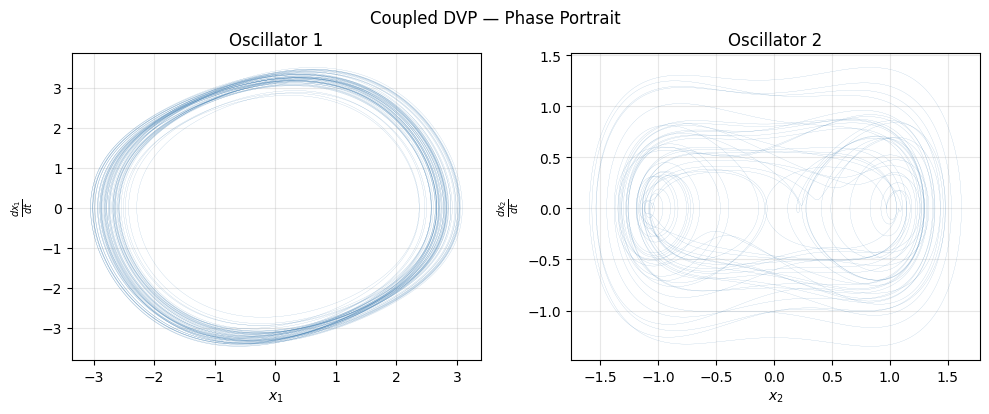

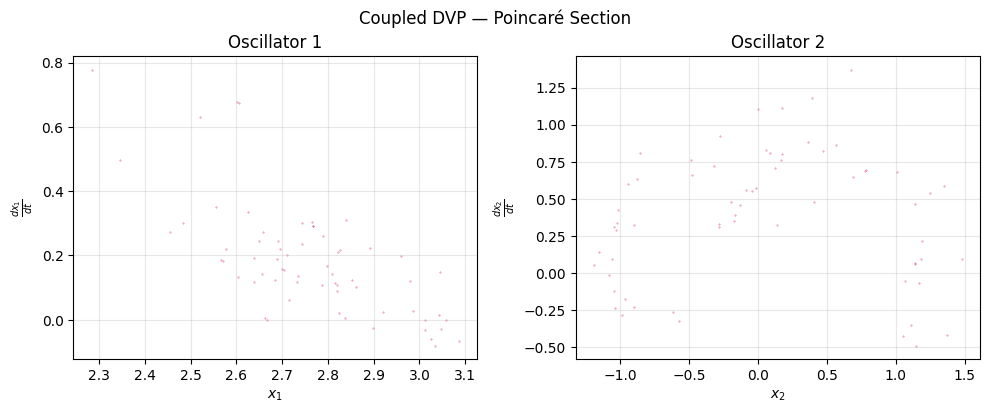

Logger initialized with file 2026-03-27_23-06-15_3e6b66df8c.log
[2026-03-27 23:06:20] [INFO] [DEF]: Simulated 50000 steps for 4 states in [0.0 hrs 0.0 mins 1.00 secs].
[2026-03-27 23:06:20] [INFO] [DEF]: Parameters:
[2026-03-27 23:06:20] [INFO] [DEF]: 	mu1                  0.1
[2026-03-27 23:06:20] [INFO] [DEF]: 	mu2                  0.1
[2026-03-27 23:06:20] [INFO] [DEF]: 	omega1               1.0
[2026-03-27 23:06:20] [INFO] [DEF]: 	omega2               1.0
[2026-03-27 23:06:20] [INFO] [DEF]: 	alpha2               1.0
[2026-03-27 23:06:20] [INFO] [DEF]: 	k                    0.17233572
[2026-03-27 23:06:20] [INFO] [DEF]: 	F1                   0.56123365
[2026-03-27 23:06:20] [INFO] [DEF]: 	F2                   0.56123365
[2026-03-27 23:06:20] [INFO] [DEF]: 	Omega                1.14652854
[2026-03-27 23:06:20] [INFO] [DEF]: 	t_start              0
[2026-03-27 23:06:20] [INFO] [DEF]: 	t_end                500
[2026-03-27 23:06:20] [INFO] [DEF]: 	transient_drop_frac  0.3
[2026-03-27 23

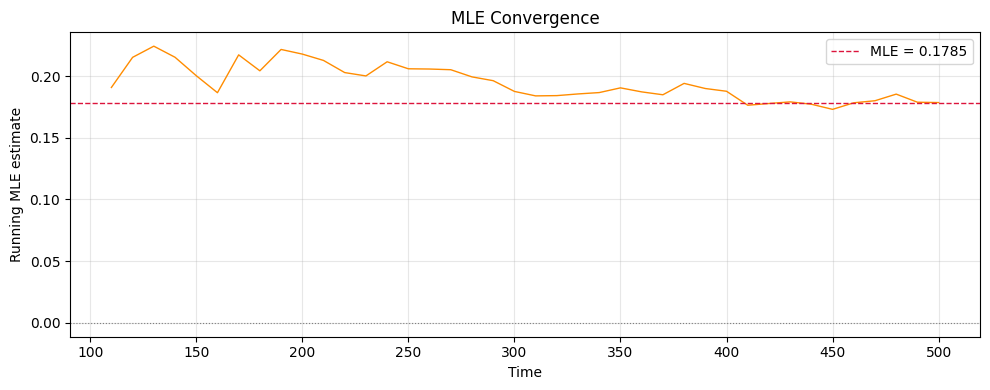

In [ ]:


# t, sol, msg = simulate(t_span=[PARAMS['t_start'],PARAMS['t_end']])
# t_trim, sol_trim = drop_transient(t, sol, frac=PARAMS['transient_drop_frac'])
# ps = poincare_section(t, sol, PARAMS)

# run = tracker.create_run(params=PARAMS, notes="Testing sampled chaos set with MLE > 0.2. Also testing verbosity")

# plot_phase_portrait(sol_trim, title="Coupled DVP — Phase Portrait", save_path=run.get_path("logs"))
# plot_poincare(ps, title="Coupled DVP — Poincare Section", save_path=run.get_path("logs"))

# run.copy_file("DVPParams.config", "")

# mle, growth_log = compute_mle(PARAMS, t_span=[PARAMS['t_start'],PARAMS['t_end']])
# logger = Logger(os.path.join(run.get_path("logs"), f"{run.uid}.log"))
# logger.start_session()
# logger(msg)
# logger(f"MLE = {mle:.4f}")
# plot_mle_convergence(growth_log, mle, save_path=run.get_path("logs"))
# logger.end_session()

In [122]:
# ps.shape

In [123]:
# t1, sol1 = simulate(x0=[0.1, 0.0, -0.1, 0.0], t_span=[0,1000])
# t2, sol2 = simulate(x0=[0.1 + 1e-5, 0.0, -0.1, 0.0], t_span=[0,1000])  # tiny perturbation

# _, sol1 = drop_transient(t1, sol1)
# _, sol2 = drop_transient(t2, sol2)

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(sol1[0], sol1[1], lw=0.3, color='steelblue', alpha=0.8, label='Trajectory 1')
# ax.plot(sol2[0], sol2[1], lw=0.3, color='crimson', alpha=0.8, label='Trajectory 2')
# ax.set_xlabel('$x_1$')
# ax.set_ylabel('$\\frac{dx_1}{dt}$')
# ax.legend()
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(figsize=(12, 3))
# end_timeseries = sol1.shape[1]
# ax.plot(t1[:end_timeseries], sol1[0, :end_timeseries], lw=0.5, color='steelblue', label='Traj 1')
# ax.plot(t2[:end_timeseries], sol2[0, :end_timeseries], lw=0.5, color='crimson', alpha=0.7, label='Traj 2')
# ax.set_xlabel('t')
# ax.set_ylabel('$x_1$')
# ax.legend()
# plt.tight_layout()
# plt.show()

In [124]:
# sol2.shape[1]

###  Sweeping parameter space to find MLE regions greater than a certain threshold

In [ ]:
from scipy.stats import qmc
from joblib import Parallel, delayed

# def mle_for_params(param_sample):
#     """
#     Single evaluation for one parameter set.
#     Returns (params_dict, mle_value).
#     """
#     F, Omega, k = param_sample

#     params = {
#         'mu1': 0.1, 'mu2': 0.1,
#         'omega1': 1.0, 'omega2': 1.0,
#         'alpha2': 1.0,
#         'k': k,
#         'F1': F, 'F2': F,
#         'Omega': Omega,
#     }

#     try:
#         mle, _ = compute_mle(params, t_span=(0, 300), verbose=False)
#         return (F, Omega, k, mle)
#     except Exception:
#         return (F, Omega, k, np.nan)

def mle_for_params(param_sample, t_span = [0,300]):
  F, Omega, k = param_sample

  params = {
      'mu1': 0.1, 'mu2': 0.1,
      'omega1': 1.0, 'omega2': 1.0,
      'alpha2': 1.0,
      'k': k,
      'F1': F, 'F2': F,
      'Omega': Omega,
  }

  try:
      mle, _ = compute_mle(params, t_span=(0, 500),
                            ts_per_sec=10)
      return (F, Omega, k, mle)
  except Exception as e:
      print(f"Failed for F={F:.2f}, Omega={Omega:.2f}, k={k:.2f}: {e}")
      return (F, Omega, k, np.nan)
  
def sweep_mle_lhs(params : dict, n_samples=500, n_jobs=-1, seed = 42):
    """
    Latin Hypercube sweep over (F, Omega, k).
    n_jobs=-1 uses all available CPU cores.
    """
    # define bounds: [F, Omega, k]
    # bounds_low  = [0.5, 0.6, 0.05]
    bounds_low  = params["bounds_low"]
    # bounds_high = [6.0, 1.5, 0.8 ]
    bounds_high  = params["bounds_high"]

    sampler = qmc.LatinHypercube(d=3, seed=seed)
    sample  = sampler.random(n=n_samples)
    samples = qmc.scale(sample, bounds_low, bounds_high)

    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(mle_for_params)(s) for s in samples
    )

    return np.array(results)#Columns: F, Omega, k, MLE

In [ ]:
params = {
    "mle_threshold" : 0.1,
    "n_samples" : 1000,
    "seed" : 42,
    "bounds_low" : [0.5, 0.6, 0.05],
    "bounds_high" :[6.0, 1.5, 0.8 ]
}

run = tracker.create_run(params, f"MLE thresholding: {params['mle_threshold']}")
logger = Logger(os.path.join(run.get_path("logs"), f"{run.uid}.log"))
logger.start_session()
logger("Sweeping for [F, Omega, k]")

results = sweep_mle_lhs(params, n_samples=params["n_samples"], seed = params["seed"])
threshold = params["mle_threshold"]
chaotic   = results[results[:, 3] > threshold]
# print(chaotic[chaotic[:, 3].argsort()[::-1]][:10])


logger(f"Found {len(chaotic)} chaotic parameter sets above MLE={threshold}")
logger("Sorted descending by MLE:")
logger(str(chaotic[chaotic[:, 3].argsort()[::-1]]))
logger.end_session()


In [128]:
# run.add_notes(f"{len(chaotic)} chaotic parameter set |  MLE>{threshold}")

In [129]:
# os.path.basename("C:\\customTools\\traning.log")

In [130]:
# save_path = None
# save_path = "" if save_path == None else save_path

# os.path.join(save_path, "test.png")